In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [23]:
df = pd.read_csv("ushape.csv")

In [24]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


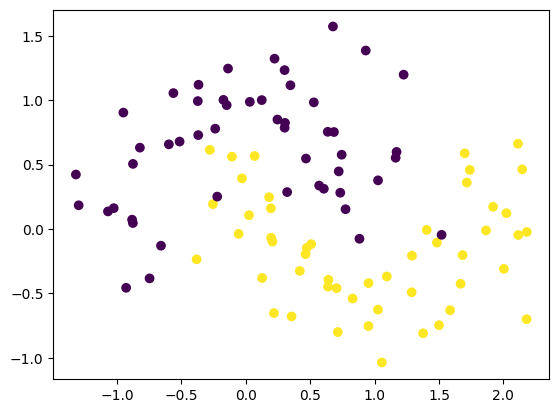

In [25]:
plt.scatter(df["X"],df['Y'],c = df['class'])

In [26]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [27]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [28]:
model = Sequential()
model.add(Dense(10,activation = 'tanh',input_dim = 2))
model.add(Dense(10,activation = 'tanh'))
model.add(Dense(10,activation = 'tanh'))
model.add(Dense(10,activation = 'tanh'))
model.add(Dense(1,activation = 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.get_weights()

[array([[ 0.6124062 , -0.16367507,  0.08404249, -0.3340829 ,  0.45565754,
         -0.1313296 ,  0.46186858,  0.11124998,  0.4706859 , -0.10918748],
        [-0.07829231,  0.00162756, -0.32250515, -0.59560764,  0.54608434,
          0.04504889,  0.5579187 , -0.25909287,  0.3729511 , -0.27529326]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.24294513,  0.20077997,  0.03487122, -0.22012633,  0.38671285,
         -0.33356118, -0.28970987,  0.3315742 , -0.03340435,  0.2733528 ],
        [-0.3492369 , -0.04817232,  0.13419485,  0.27301824,  0.4919356 ,
         -0.34268624, -0.48179507, -0.49218905,  0.34556258, -0.09777927],
        [ 0.30557048, -0.45835665,  0.43091506, -0.4133833 ,  0.04867166,
         -0.02928591,  0.25296682, -0.13769183, -0.02229947, -0.36436543],
        [-0.06103373, -0.16855326, -0.4740835 , -0.50139743,  0.2026611 ,
         -0.38242918, -0.01992434,  0.4386869 ,  0.06484622,  0.5203639 ],
        [ 0.33314

In [30]:
initial_weights = model.get_weights()

In [31]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10);
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10);
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10);
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [32]:
model.set_weights(initial_weights)

In [33]:
model.get_weights()

[array([[-0.950799  ,  0.9385741 ,  0.4947595 , -0.56237316,  0.00622011,
         -1.1247814 , -1.6770974 ,  0.56422085,  1.1255916 , -0.5662199 ],
        [ 0.36292148,  0.06014778,  0.5443058 , -0.52690005, -0.4555279 ,
         -0.26338285,  0.08609421, -0.5333414 ,  0.8247428 , -0.48253644]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.22656247,  0.06575235, -0.4632914 , -0.24646354, -0.28762233,
         -0.11472572, -0.39950114,  0.36489704,  0.20004801, -0.31102785],
        [-0.07585743, -0.1760693 ,  0.32107696,  0.15562177, -0.32556406,
          0.39074358,  0.2541217 ,  0.16878156,  0.26236808,  0.00241101],
        [ 0.42923582, -0.04154915, -0.59815294, -0.02175345, -0.29551136,
         -0.1412244 , -0.2082343 , -0.1216379 , -0.09911475, -0.1316985 ],
        [ 0.47123846,  0.7939459 , -0.4296056 ,  0.10571384,  0.1653925 ,
         -0.3626269 ,  0.10749138,  0.15059063,  0.42638966, -0.02578176],
        [-0.09173

In [34]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [36]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9500 - loss: 0.1420 - val_accuracy: 1.0000 - val_loss: 0.0513
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9500 - loss: 0.1405 - val_accuracy: 1.0000 - val_loss: 0.0480
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9500 - loss: 0.1399 - val_accuracy: 1.0000 - val_loss: 0.0501
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9500 - loss: 0.1392 - val_accuracy: 1.0000 - val_loss: 0.0528
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9500 - loss: 0.1386 - val_accuracy: 1.0000 - val_loss: 0.0553
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9500 - loss: 0.1383 - val_accuracy: 1.0000 - val_loss: 0.0608
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9500 - loss: 0.1385 - val_accuracy: 1.0000 - val_loss: 0.0637
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9500 - loss: 0.1377 - val_accuracy: 0.9500 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


<Axes: >

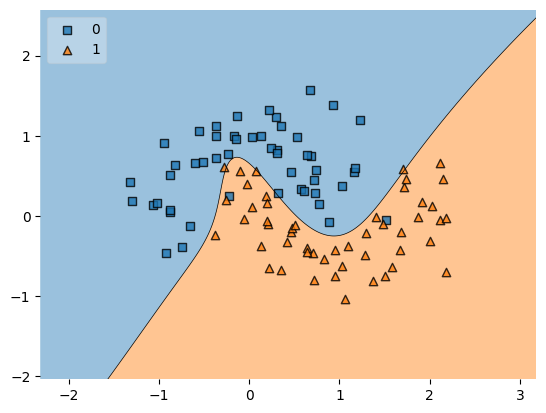

In [37]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'), clf=model, legend=2)